In [1]:

# TASK 1: HISTORICAL VaR & CVaR

import pandas as pd
import numpy as np

# Loading dataset:
returns = pd.read_csv("../Data/Processed/daily_returns.csv")

# Calculating VaR and CVaR for each fund:
results = []

for fund, group in returns.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()

    var_95 = np.percentile(daily_returns, 5)
    cvar_95 = daily_returns[daily_returns <= var_95].mean()

    results.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

# Creating output table:
var_cvar = pd.DataFrame(results)

# Save output:
var_cvar.to_csv("../Data/Processed/var_cvar_report.csv", index=False)

# Checking result:
print(var_cvar.head())
print("\nFunds analysed:", len(var_cvar))
print("\nSaved: Data/Processed/var_cvar_report.csv")

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459

Funds analysed: 40

Saved: Data/Processed/var_cvar_report.csv


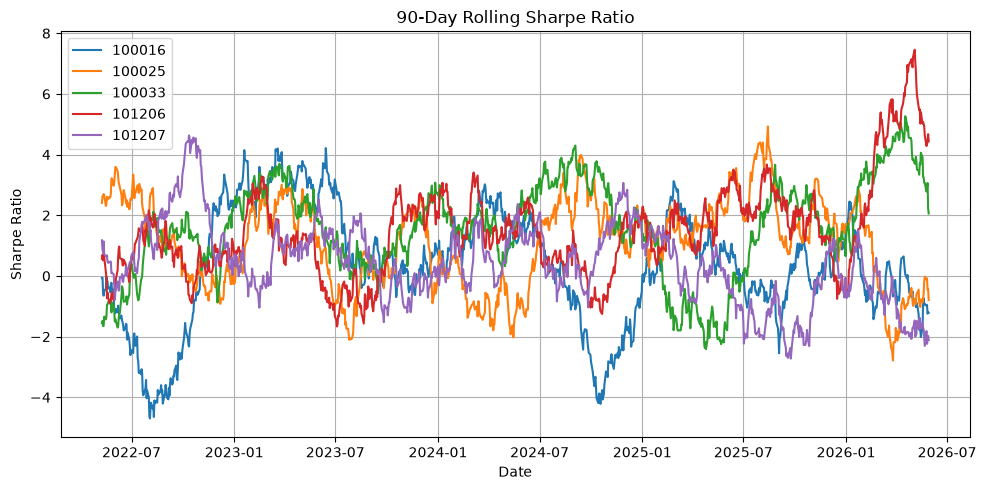

Saved: Reports/rolling_sharpe_chart.png


In [2]:

# TASK 2: ROLLING 90-DAY SHARPE RATIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading dataset:
returns = pd.read_csv("../Data/Processed/daily_returns.csv")
returns["date"] = pd.to_datetime(returns["date"])

# Selecting 5 funds:
funds = returns["amfi_code"].dropna().unique()[:5]

# Calculating rolling 90-day Sharpe Ratio:
plt.figure(figsize=(10, 5))

for fund in funds:
    data = returns[returns["amfi_code"] == fund].sort_values("date").copy()

    rolling_mean = data["daily_return"].rolling(90).mean()
    rolling_std = data["daily_return"].rolling(90).std()

    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    plt.plot(data["date"], sharpe, label=str(fund))

# Creating chart:
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 5. Save chart:
plt.savefig("../Reports/rolling_sharpe_chart.png", dpi=150)
plt.show()

print("Saved: Reports/rolling_sharpe_chart.png")

In [ ]:

# TASK 3 — INVESTOR COHORT ANALYSIS

import pandas as pd
from pathlib import Path


# Loading cleaned investor transactions:
root = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / "Data" / "Processed").exists()
)

df = pd.read_csv(
    root / "Data" / "Processed" / "investor_transactions_cleaned.csv"
)

print("Dataset loaded successfully.")


# Calculating each investor's first transaction year:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

first_year = (
    df.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

df["first_transaction_year"] = first_year


# Selecting 2024 and 2025 cohorts:
cohort = df[
    df["first_transaction_year"].isin([2024, 2025])
].copy()


# Calculating cohort metrics:
sip = cohort[
    cohort["transaction_type"].str.upper() == "SIP"
]

summary = (
    cohort.groupby("first_transaction_year")
    .agg(
        total_invested_inr=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

sip_avg = (
    sip.groupby("first_transaction_year")["amount_inr"]
    .mean()
    .rename("average_sip_amount_inr")
)

summary = summary.merge(
    sip_avg,
    on="first_transaction_year",
    how="left"
)


# Finding preferred fund for each cohort:
preferred_fund = (
    cohort.groupby(["first_transaction_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
    .sort_values(
        ["first_transaction_year", "transactions"],
        ascending=[True, False]
    )
    .drop_duplicates("first_transaction_year")
    .rename(columns={"amfi_code": "preferred_fund"})
)

summary = summary.merge(
    preferred_fund[["first_transaction_year", "preferred_fund"]],
    on="first_transaction_year",
    how="left"
)


# Display and save result:
display(summary)

summary.to_csv(
    root / "Data" / "Processed" / "cohort_analysis.csv",
    index=False
)

print("Task 3 completed successfully.")

Dataset loaded successfully.


,first_transaction_year,total_invested_inr,investors,average_sip_amount_inr,preferred_fund
0,2024,3491125187,4803,10996.885825,148568
1,2025,30455243,197,13505.209581,119599


Task 3 completed successfully.


In [ ]:

# TASK 4 — SIP CONTINUATION ANALYSIS

import pandas as pd
from pathlib import Path

# Finding project folder and loading data:
root = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / "Data" / "Processed").exists()
)

df = pd.read_csv(
    root / "Data" / "Processed" / "investor_transactions_cleaned.csv"
)

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Keeping only SIP transactions:
sip = df[
    df["transaction_type"].str.upper() == "SIP"
].copy()

# Sorting transactions by investor and date:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

# Calculating gap between consecutive SIP transactions:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Keeping investors with 6 or more SIP transactions:
sip_count = (
    sip.groupby("investor_id")
    .size()
    .rename("sip_transactions")
)

eligible = sip_count[sip_count >= 6].index

sip = sip[
    sip["investor_id"].isin(eligible)
]


# Calculating SIP continuity metrics:
continuity = (
    sip.groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "count"),
        average_gap_days=("gap_days", "mean"),
        maximum_gap_days=("gap_days", "max")
    )
    .reset_index()
)

# Flaging investors with a gap greater than 35 days:
continuity["risk_flag"] = continuity[
    "maximum_gap_days"
].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

# Display result:
display(continuity)


# Save output:
continuity.to_csv(
    root / "Data" / "Processed" / "sip_continuity.csv",
    index=False
)

print("Task 4 completed successfully.")
print("Saved: Data/Processed/sip_continuity.csv")

,investor_id,sip_transactions,average_gap_days,maximum_gap_days,risk_flag
0,INV000004,6,85.400000,265.0,At-Risk
1,INV000008,6,70.400000,165.0,At-Risk
2,INV000010,6,64.800000,139.0,At-Risk
3,INV000011,7,40.166667,125.0,At-Risk
4,INV000012,8,57.000000,132.0,At-Risk
...,...,...,...,...,...
1357,INV004984,7,75.333333,177.0,At-Risk
1358,INV004986,7,81.333333,185.0,At-Risk
1359,INV004992,7,81.500000,176.0,At-Risk
1360,INV004996,10,46.333333,104.0,At-Risk


Task 4 completed successfully.
Saved: Data/Processed/sip_continuity.csv


In [ ]:

# TASK 5 — SIMPLE FUND RECOMMENDATION MODEL


from pathlib import Path
import pandas as pd


# Finding project folder:
root = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / "Data" / "Processed").exists()
)


# Loading scheme performance data:
file_path = root / "Data" / "Processed" / "scheme_performance_cleaned.csv"

funds = pd.read_csv(file_path)


# Cleaning column names:
funds.columns = funds.columns.str.strip()


# Recommendating function:
def recommend_funds(risk_grade, top_n=3):

    result = funds[
        funds["risk_grade"].astype(str).str.strip().str.lower()
        == risk_grade.strip().lower()
    ].copy()

    result = result.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(top_n)

    return result[
        [
            "scheme_name",
            "fund_house",
            "category",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]


# Testing recommendations:
for risk in ["Low", "Moderate", "High"]:

    print(f"\n===== {risk.upper()} RISK =====")

    display(
        recommend_funds(risk)
    )

# Save the recommendation script:
script = '''import pandas as pd

funds = pd.read_csv(
    "Data/Processed/scheme_performance_cleaned.csv"
)

def recommend_funds(risk_grade, top_n=3):

    result = funds[
        funds["risk_grade"].astype(str).str.strip().str.lower()
        == risk_grade.strip().lower()
    ].copy()

    return result.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(top_n)[
        [
            "scheme_name",
            "fund_house",
            "category",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]
'''

(root / "recommender.py").write_text(
    script,
    encoding="utf-8"
)

print("\nTask 5 completed successfully.")
print("Created: recommender.py")


===== LOW RISK =====


,scheme_name,fund_house,category,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Low,5.14



===== MODERATE RISK =====


,scheme_name,fund_house,category,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03



===== HIGH RISK =====


,scheme_name,fund_house,category,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High,0.95
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,High,0.90



Task 5 completed successfully.
Created: recommender.py


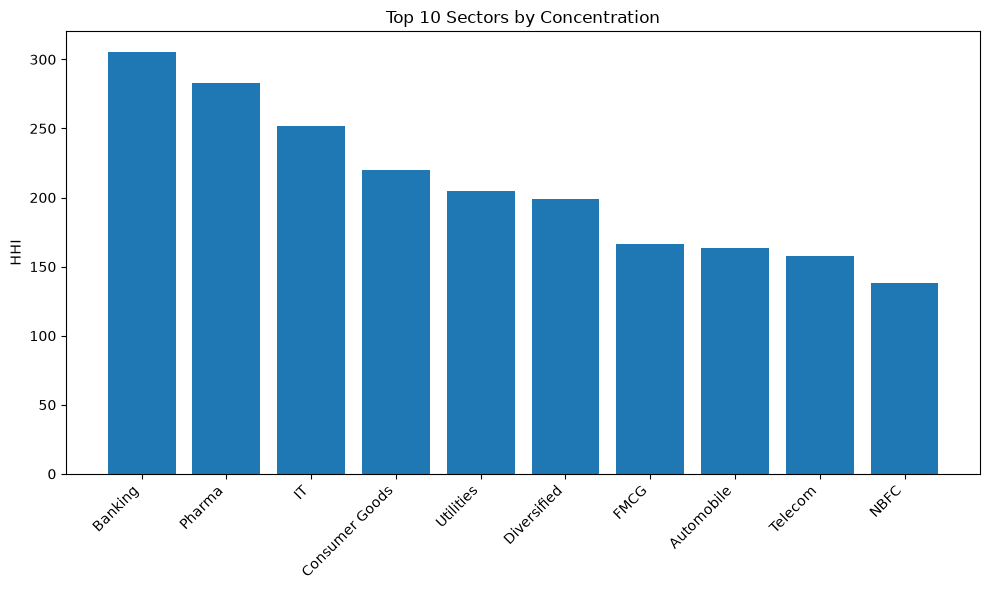

Task 6 completed successfully.
            sector         HHI
1          Banking  305.058173
11          Pharma  283.064423
7               IT  252.014233
3   Consumer Goods  220.054344
13       Utilities  204.720200
4      Diversified  199.166436
6             FMCG  166.225889
0       Automobile  163.419696
12         Telecom  158.020493
9             NBFC  137.962555


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading Data:
df = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

sector_hhi = (
    df.groupby(["amfi_code", "sector"])["weight_pct"]
      .apply(lambda x: (x ** 2).sum())
      .reset_index(name="HHI")
)

sector_hhi = (
    sector_hhi.groupby("sector")["HHI"]
    .mean()
    .reset_index()
    .sort_values("HHI", ascending=False)
)

# CSV → Data/Processed:
sector_hhi.to_csv("../Data/Processed/sector_hhi.csv", index=False)

# PNG → Existing Reports folder:
top10 = sector_hhi.head(10)

# Creating bar chart for top 10 sectors by HHI:
plt.figure(figsize=(10, 6))
plt.bar(top10["sector"], top10["HHI"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("HHI")
plt.title("Top 10 Sectors by Concentration")
plt.tight_layout()
plt.savefig("../Reports/sector_hhi_chart.png", dpi=150)
plt.show()

# Print results:
print("Task 6 completed successfully.")
print(sector_hhi.head(10))

In [ ]:
# TASK 7 — ADVANCED ANALYTICS SUMMARY

import pandas as pd
from pathlib import Path

processed = Path("../Data/Processed")

# Loading Day 6 outputs:
var = pd.read_csv(processed / "var_cvar_report.csv")
cohort = pd.read_csv(processed / "cohort_analysis.csv")
sip = pd.read_csv(processed / "sip_continuity.csv")
hhi = pd.read_csv(processed / "sector_hhi.csv")

print("=" * 60)
print("DAY 6 — ADVANCED ANALYTICS SUMMARY")
print("=" * 60)

# Highest VaR funds:
print("\n1. HIGHEST RISK FUNDS")
print(var.head(5).to_string(index=False))

# Investor cohorts:
print("\n2. INVESTOR COHORT ANALYSIS")
print(cohort.head(5).to_string(index=False))

# SIP continuation:
print("\n3. SIP CONTINUATION")
print(sip.head(5).to_string(index=False))

# Sector concentration:
print("\n4. SECTOR CONCENTRATION")
print(hhi.head(5).to_string(index=False))

# Overall observations:
print("\n5. KEY INSIGHTS")
print("""
• VaR/CVaR analysis identifies funds with comparatively higher historical downside risk.
• Investor cohort analysis shows differences in investment behaviour across first-transaction years.
• SIP continuation analysis identifies investors with longer or interrupted SIP participation.
• Sector HHI highlights sectors where portfolio exposure is more concentrated.
• These risk, investor-behaviour and concentration metrics can support better fund selection and portfolio diversification decisions.
""")

print("\nTask 7 completed successfully.")

DAY 6 — ADVANCED ANALYTICS SUMMARY

1. HIGHEST RISK FUNDS
 amfi_code    VaR_95   CVaR_95
    100016 -0.014364 -0.018060
    100025 -0.003793 -0.004994
    100033 -0.019034 -0.023456
    101206 -0.013282 -0.017439
    101207 -0.026021 -0.032459

2. INVESTOR COHORT ANALYSIS
 first_transaction_year  total_invested_inr  investors  average_sip_amount_inr  preferred_fund
                   2024          3491125187       4803            10996.885825          148568
                   2025            30455243        197            13505.209581          119599

3. SIP CONTINUATION
investor_id  sip_transactions  average_gap_days  maximum_gap_days risk_flag
  INV000004                 6         85.400000             265.0   At-Risk
  INV000008                 6         70.400000             165.0   At-Risk
  INV000010                 6         64.800000             139.0   At-Risk
  INV000011                 7         40.166667             125.0   At-Risk
  INV000012                 8         57.